In [64]:
import cv2
import mediapipe as mp
import csv
import math
import pandas as pd
import json
import matplotlib.pyplot as plt


In [42]:
def write_landmarks_to_csv(landmarks, timestamp, csv_data):
    print(f"Landmark coordinates for frame {timestamp}:")
    for idx, landmark in enumerate(landmarks):
        # print(f"idx: {idx}, {mp_pose.PoseLandmark(idx).name}: (x: {landmark.x}, y: {landmark.y}, z: {landmark.z})")
        csv_data.append([timestamp, mp_pose.PoseLandmark(idx).name, landmark.x, landmark.y, landmark.z])
    print("\n")

def process_video(video_in_file, json_out_file, sampling_frequency=3):
    cap = cv2.VideoCapture(video_in_file)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = -1
    
    landmarks_json = dict() # timestamp : [landmarks]
    while cap.isOpened():
        ret, frame = cap.read()
        frame_count += 1
        
        timestamp = float(frame_count / fps) # timestamp in seconds of this frame
        
        if frame_count % sampling_frequency != 0: # only record body poses with sampling_frequency frequency
            # print('ignoring timestamp:', timestamp, 'params: timestamp', timestamp, 'sampling_frequency', sampling_frequency)
            # TODO debug this sampling frequency
            continue

        if not ret: # TODO make this more robust?
            break
        
        # Convert the frame to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Process the frame with MediaPipe Pose
        result = pose.process(frame_rgb)

        # Draw the pose landmarks on the frame
        # if result.pose_landmarks:
            # mp_drawing.draw_landmarks(frame, result.pose_landmarks, mp_pose.POSE_CONNECTIONS)

        landmarks = dict()
        for idx, landmark in enumerate(result.pose_landmarks.landmark):
            landmarks[mp_pose.PoseLandmark(idx).name] = [landmark.x, landmark.y, landmark.z]
        landmarks_json[timestamp] = landmarks
        # Display the frame
        # cv2.imshow('MediaPipe Pose', frame)

        # Exit if 'q' keypyt
    # print(landmarks_json[0])
    with open(json_out_file, 'w', encoding='utf-8') as json_file:
        json.dump(landmarks_json, json_file, ensure_ascii=False, indent=4)
    return landmarks_json
    

# Initialize MediaPipe Pose and Drawing utilities
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose()


landmarks_json = process_video(video_in_file='./r_arm.mov', json_out_file='landmarks.json') # also returns the json

I0000 00:00:1744172240.783863 8389293 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M2
W0000 00:00:1744172240.937824 8425914 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1744172240.961826 8425920 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [47]:
def find_angle(point1, point2):
    # return the angles in the x, y, and z directions
    vector = (point2[0] - point1[0], point2[1] - point1[1], point2[2] - point1[2])
    magnitude = math.sqrt(vector[0]**2 + vector[1]**2 + vector[2]**2)
    
    cos_theta_x = vector[0] / magnitude
    cos_theta_y = vector[1] / magnitude
    cos_theta_z = vector[2] / magnitude
    
    theta_x = math.degrees(math.acos(cos_theta_x))
    theta_y = math.degrees(math.acos(cos_theta_y))
    theta_z = math.degrees(math.acos(cos_theta_z))
    return theta_x, theta_y, theta_z

In [48]:
times = sorted(landmarks_json.keys())
print(times) # lists each timestamp at which we have saved the body pose. This can be adjusted with the sampling_frequency parameter

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.4]


In [ ]:
def get_angles(point1_name, point2_name, angle_axis):
    angles = []
    for time in times:
        point1 = landmarks_json[time][point1_name]
        point2 = landmarks_json[time][point2_name]
        angle = find_angle(point1, point2)
        wanted_angles = angle[angle_axis]
        angles.append(wanted_angles)
    return angles

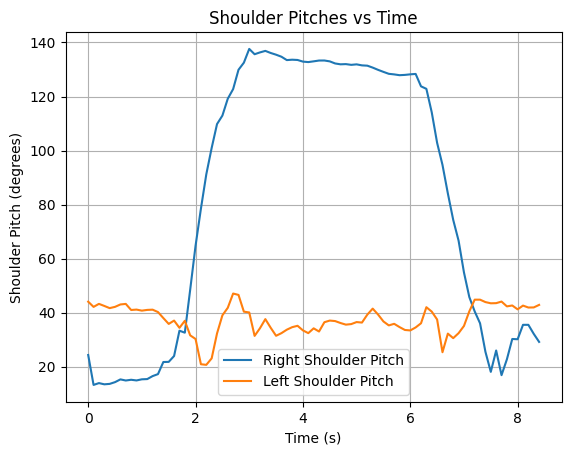

In [72]:
r_shoulder_pitches = get_angles('RIGHT_SHOULDER', 'RIGHT_ELBOW', 0)
l_shoulder_pitches = get_angles('LEFT_SHOULDER', 'LEFT_ELBOW', 0)

# Plot the right shoulder pitches as a function of time
plt.plot(times, r_shoulder_pitches, label='Right Shoulder Pitch')
plt.plot(times, l_shoulder_pitches, label='Left Shoulder Pitch')
plt.xlabel('Time (s)')
plt.ylabel('Shoulder Pitch (degrees)')
plt.title('Shoulder Pitches vs Time')
plt.legend()
plt.grid(True)
plt.show()